# **Emotion Recognition from Speech**

### **CodeAlpha Machine Learning Internship - Task 2**

**Intern Name:** Radhika

**Platform:** Google Colab

**Programming Language:** Machine Learning

## Dataset Preparation

In this step, the RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song) dataset is loaded and organized.

The dataset contains speech recordings representing different emotions such as:

- Neutral
- Calm
- Happy
- Sad
- Angry
- Fearful
- Disgust
- Surprised

Audio files are collected from all actor folders and corresponding emotion labels are extracted from the filenames for further processing.

## Mount Google Drive

The Google Drive is mounted to access the RAVDESS dataset stored in the user's drive. This allows the notebook to read audio files directly from Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install & Import Required Libraries

Required libraries are installed and imported for audio processing, data handling, visualization, machine learning, and deep learning model development.

Libraries Used:
- Librosa (Audio Feature Extraction)
- NumPy (Numerical Computation)
- Pandas (Data Handling)
- Matplotlib & Seaborn (Visualization)
- Scikit-learn (Preprocessing and Data Splitting)
- TensorFlow/Keras (Deep Learning Model)

In [ ]:
!pip install librosa soundfile tensorflow -q

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dropout
from tensorflow.keras.utils import to_categorical

## Verify Dataset Location

The dataset path is checked to ensure that the RAVDESS dataset is correctly loaded from Google Drive before further processing.

In [ ]:
dataset_path = "/content/drive/MyDrive/RAVDESS"

In [ ]:
print(os.listdir(dataset_path)[:5])

['archive (1)']


## Explore Dataset Structure

The RAVDESS dataset is organized into multiple actor folders. This step verifies the folder structure and counts the total number of actors available in the dataset.

In [ ]:
print(os.listdir("/content/drive/MyDrive/RAVDESS/archive (1)")[:5])

['Actor_01', 'Actor_23', 'Actor_22', 'Actor_20', 'Actor_24']


In [ ]:
actors = os.listdir("/content/drive/MyDrive/RAVDESS/archive (1)")
print("Total Actors:", len(actors))

Total Actors: 25


## Extract Emotion Labels

Each audio filename in the RAVDESS dataset contains an emotion code. These codes are mapped to their corresponding emotion labels such as Happy, Sad, Angry, Fearful, Calm, Neutral, Disgust, and Surprised.

Audio file paths and emotion labels are collected for model training.

In [ ]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

data = []
labels = []

dataset_path = "/content/drive/MyDrive/RAVDESS/archive (1)"

for actor in os.listdir(dataset_path):
    actor_path = os.path.join(dataset_path, actor)

    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):

            if file.endswith(".wav"):

                emotion_code = file.split("-")[2]

                if emotion_code in emotion_map:

                    file_path = os.path.join(actor_path, file)

                    data.append(file_path)
                    labels.append(emotion_map[emotion_code])

print("Total Audio Files:", len(data))
print("Sample Labels:", labels[:10])

Total Audio Files: 1440
Sample Labels: ['fearful', 'surprised', 'fearful', 'happy', 'fearful', 'sad', 'disgust', 'surprised', 'disgust', 'calm']


## Feature Extraction using MFCC

Mel-Frequency Cepstral Coefficients (MFCCs) are extracted from each audio file. MFCC features capture important characteristics of speech signals and are widely used in speech emotion recognition tasks.

For each audio sample:
- Audio is loaded
- MFCC features are extracted
- Mean values are computed to create a fixed-length feature vector

In [ ]:
def extract_features(file_path):
    audio, sample_rate = librosa.load(file_path, duration=3, offset=0.5)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    return np.mean(mfcc.T, axis=0)

## Generate Feature Dataset
The feature extraction function is applied to all audio files in the dataset. The resulting MFCC feature vectors are stored along with their corresponding emotion labels to create the final dataset for model training.

In [ ]:
X = []
y = []

for file_path, label in zip(data, labels):
    try:
        feature = extract_features(file_path)

        X.append(feature)
        y.append(label)

    except:
        pass

print("Features Extracted:", len(X))

Features Extracted: 1440


## Label Encoding

Machine learning models work with numerical values rather than text labels. Therefore, emotion labels are converted into numerical form using Label Encoding.

The encoded labels are then transformed into categorical format using One-Hot Encoding, making them suitable for multi-class classification.

In [ ]:
X = np.array(X)
y = np.array(y)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

## Train-Test Split

The dataset is divided into training and testing sets.

- Training Set: Used to train the model.
- Testing Set: Used to evaluate model performance on unseen data.

This helps assess the model's ability to generalize to new speech samples.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42
)

## Build CNN Model

A Convolutional Neural Network (CNN) is created to learn patterns from MFCC audio features.

The model consists of:
- Convolution Layers for feature learning
- Max Pooling Layers for dimensionality reduction
- Dropout Layers to prevent overfitting
- Dense Layers for classification

The final output layer predicts the emotion category of the speech sample.

In [ ]:
model = Sequential()
...

In [ ]:
model = Sequential()

model.add(Conv1D(64, 3, activation='relu',
                 input_shape=(X_train.shape[1], 1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(128, 3, activation='relu'))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(y_categorical.shape[1],
                activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,192 (614.03 KB)

 Trainable params: 157,192 (614.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(1152, 40)
(1152, 8)


## Model Compilation

The CNN model is compiled using:

- Adam Optimizer for efficient learning
- Categorical Crossentropy Loss for multi-class classification
- Accuracy as the evaluation metric

This prepares the model for training.

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Model Training

The CNN model is trained using the extracted MFCC features and encoded emotion labels.

During training:
- The model learns emotional speech patterns.
- Validation data is used to monitor performance.
- Accuracy and loss values are recorded for analysis.

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.1675 - loss: 3.6326 - val_accuracy: 0.2222 - val_loss: 1.9734
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2092 - loss: 2.0147 - val_accuracy: 0.2535 - val_loss: 1.9349
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1918 - loss: 1.9955 - val_accuracy: 0.2292 - val_loss: 1.9504
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2075 - loss: 1.9584 - val_accuracy: 0.3194 - val_loss: 1.8572
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2439 - loss: 1.9256 - val_accuracy: 0.2847 - val_loss: 1.8474
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2465 - loss: 1.8992 - val_accuracy: 0.3125 - val_loss: 1.8351
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2552 - loss: 1.8642 - val_accuracy: 0.2708 - val_loss: 1.8362
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2587 - loss: 1.8668 - val_accuracy: 0.3576 - val_los

## Model Evaluation

The trained model is evaluated on the testing dataset.

Evaluation metrics such as accuracy are used to measure how effectively the model can recognize emotions from unseen speech samples.

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4896 - loss: 1.3923 
Accuracy: 0.4895833432674408


## Training Performance Visualization

Training and validation accuracy/loss graphs are plotted to analyze the learning behavior of the model.

These visualizations help identify:
- Model convergence
- Overfitting
- Underfitting
- Overall training performance

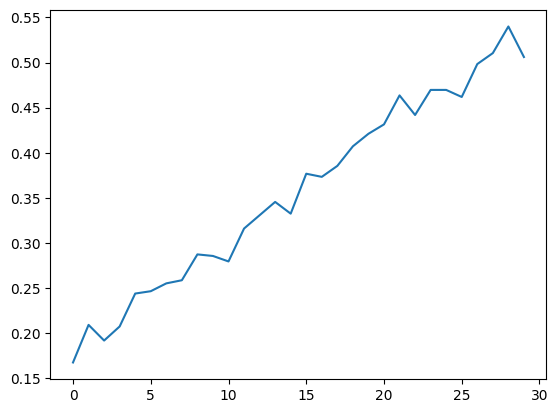

In [ ]:
plt.plot(history.history['accuracy'])

## Training Accuracy Graph

The graph below shows how the model's training accuracy changes across epochs.
A continuously increasing curve indicates that the CNN model is learning emotional speech patterns from the extracted MFCC features.

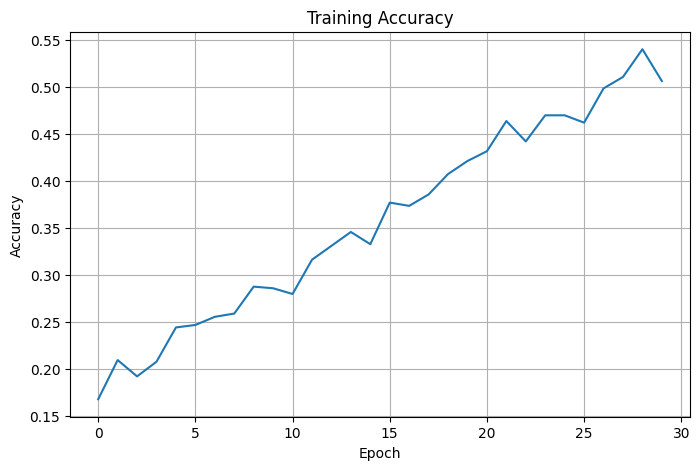

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

## Validation Accuracy Graph

Validation accuracy is used to measure how well the model performs on unseen data.
This helps determine whether the model generalizes well beyond the training dataset.

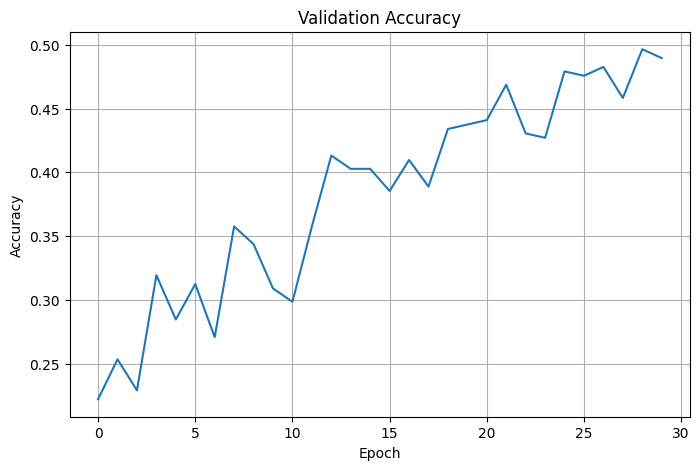

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['val_accuracy'])
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

## Training Loss Graph

Training loss represents the error made by the model during training.
A decreasing loss value indicates that the model is improving its predictions over time.

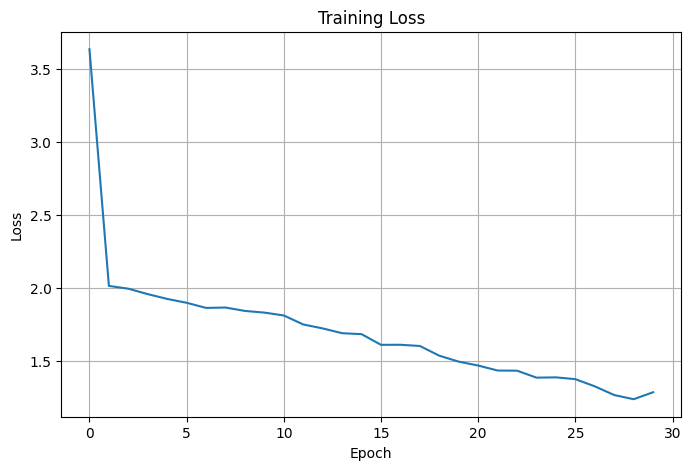

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## Validation Loss Graph

Validation loss is calculated using unseen test samples.
Monitoring validation loss helps identify overfitting and evaluate model performance on real-world data.

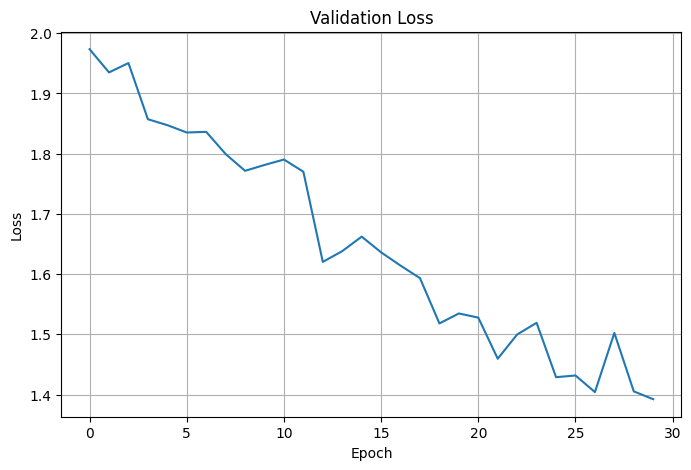

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['val_loss'])
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

## Model Saving

After training and evaluation, the trained CNN model is saved in Keras format (.keras). This allows the model to be reused later without retraining and avoids legacy HDF5 warnings.

In [ ]:
model.save('emotion_recognition_model.keras')

print("Model Saved Successfully")

Model Saved Successfully


## Project Conclusion

A Speech Emotion Recognition System was successfully developed using
MFCC feature extraction and a Convolutional Neural Network (CNN).

The model was trained and evaluated on emotional speech data and achieved
approximately 49% test accuracy.

This project demonstrates the application of Deep Learning techniques
for automatic emotion recognition from audio signals.